In [1]:
#Selektivne reportovanie zavislych premennych

C:\Users\puvak\AppData\Local\Temp\ipykernel_20524\3844510310.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


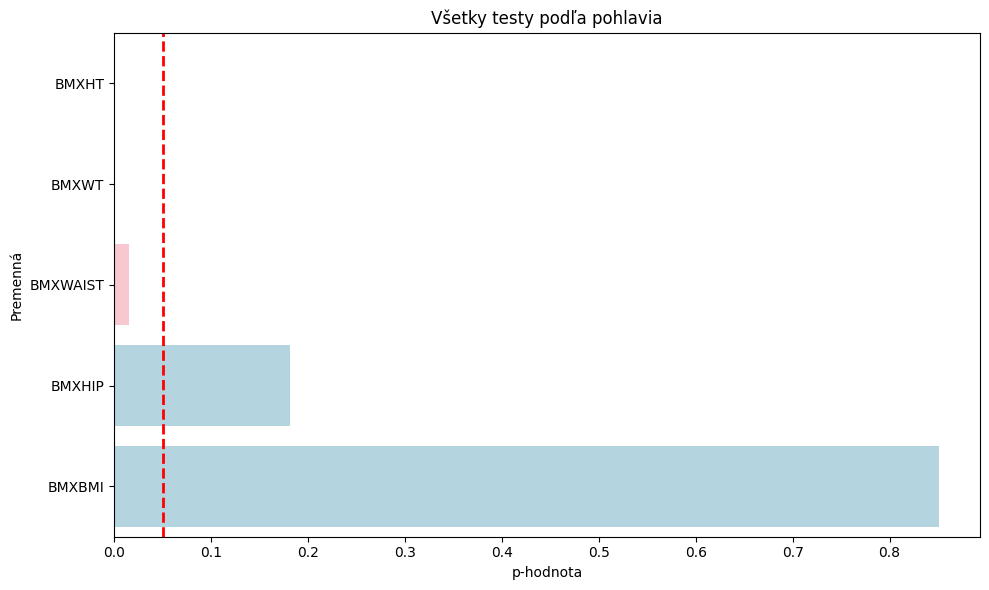


Selektívny výber – signifikantné premenné:
   Premenná  p-hodnota
4     BMXHT   0.000000
1     BMXWT   0.000588
2  BMXWAIST   0.015618


,Premenná,p-hodnota
4,BMXHT,0.000000
1,BMXWT,0.000588
2,BMXWAIST,0.015618
3,BMXHIP,0.181466
0,BMXBMI,0.850825


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import sys
import os

sys.path.append(os.path.abspath(".."))
import settings

# nacitanie dat
def load_file(file_path):
    return pd.read_sas(file_path, format='xport')

def merge_files(file1, file2):
    return pd.merge(file1, file2[['SEQN','RIDAGEYR','RIAGENDR']], on='SEQN', how='left')

bmx = load_file(settings.bmx_path)
demo = load_file(settings.demo_path)
df = merge_files(bmx, demo)

# priprava dat
df = df[df['RIDAGEYR'] >= 18]  # len dospelí
df = df.dropna(subset=['BMXBMI'])  
df['Pohlavie'] = df['RIAGENDR'].map({1:'Muži', 2:'Ženy'})

# selektivny report
def selective_reporting_gender(df, sample_size=100, random_state=10):
    variables = ['BMXBMI','BMXWT','BMXWAIST','BMXHIP','BMXHT']

    sample = df.sample(n=sample_size, random_state=random_state)
    male = sample[sample['Pohlavie']=='Muži']
    female = sample[sample['Pohlavie']=='Ženy']

    results = []

    for var in variables:
        # kontrola velkosti vzorky
        if male[var].dropna().shape[0] < 10 or female[var].dropna().shape[0] < 10:
            continue

        # Welchov t-test
        stat, p = ttest_ind(male[var].dropna(), female[var].dropna(), equal_var=False)

        results.append({
            "Premenná": var,
            "p-hodnota": round(p,6)
        })

    # zoradenie podla p-hodnoty
    df_res = pd.DataFrame(results).sort_values("p-hodnota")

    # graf vsetkych premennych
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=df_res, 
        x="p-hodnota", 
        y="Premenná",
        palette=['pink' if x<0.05 else 'lightblue' for x in df_res["p-hodnota"]]
    )
    plt.axvline(0.05, linestyle="--", color='red', lw=2, label='Signifikantné p=0.05')
    plt.title("Všetky testy podľa pohlavia")
    plt.tight_layout()
    plt.savefig("vsetky_testy_gender.png", dpi=300)  
    plt.show()

    # --- Tabuľka selektívneho výberu ---
    df_sig = df_res[df_res["p-hodnota"] < 0.05]  # len signifikantné
    df_sig.to_csv("selective_reporting_gender.csv", index=False) 

    print("\nSelektívny výber – signifikantné premenné:")
    print(df_sig)

    return df_res

selective_reporting_gender(df)

Selektívne reportovanie závislých premenných nastáva, keď sa výskumník rozhodne prezentovať iba tie výsledky, ktoré vyšli ako štatisticky významné. V tomto prípade nezávislá premenná — pohlavie — rozdeľuje údaje do dvoch skupín a podľa tohto faktora sa porovnávajú ostatné závislé premenné. Opäť budeme testovať normalitu dát, rovnosť rozptylov a následne podľa toho použijeme vhodný test. Výsledok testu zanalyzujeme a zistíme, či je štatisticky významný alebo nie. 

Keď sa pozrieme na graf krivky a selektívny report, vidíme jednak čiary, ktoré zobrazujú priemerné hodnoty vo vekových skupinách (muži aj ženy) a potom vidíme buď čiarkovanú (muži) alebo bodkovanú (ženy) čiaru. Táto vodorovná čiara spája dve vekové skupiny. Ďalej môžeme vidieť buď * alebo ** nad čiarami spájajúcimi vekové skupiny, tie predstavujú štatisticky významný rozdiel medzi vekovými skupinami, teda predstavujú výsledky, ktoré môžeme prezentovať. 
